In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Portfolio = {
    "CDSL.NS" : {
        "shares":10,
        "buy_price":11820.60,
        "average_price":1182.06
    },
    "DEVYANI.NS":{
        "shares":30,
        "buy_price":3483,
        "average_price":116.11

    },
    "IREDA.NS":{
        "shares":30,
        "buy_price": 3654.30,
        "average_price":121.81
    },
    "PLAZACABLE.NS":{
        "shares":20,
        "buy_price":1100,
        "average_price":55
    }
}

In [3]:
data = yf.download(list(Portfolio.keys()), period="1y", progress=False)
data

Price             Close                                               High  \
Ticker          CDSL.NS  DEVYANI.NS    IREDA.NS PLAZACABLE.NS      CDSL.NS   
2025-05-29  1500.763672  170.080002  175.718307     59.810001  1525.561485   
2025-05-30  1517.328613  167.589996  173.808426     59.750000  1541.432137   
2025-06-02  1669.289673  169.080002  174.285904     62.240002  1684.267528   
2025-06-03  1695.079346  166.929993  171.818970     62.860001  1716.008676   
2025-06-04  1687.540894  168.320007  173.082275     62.580002  1732.176959   
...                 ...         ...         ...           ...          ...   
2026-05-22  1204.099976  114.400002  129.009995     47.130001  1209.800049   
2026-05-25  1217.400024  116.040001  129.770004     47.540001  1224.000000   
2026-05-26  1226.300049  116.389999  129.539993     46.779999  1232.400024   
2026-05-27  1243.800049  117.160004  130.199997     47.500000  1249.800049   
2026-05-29  1260.000000  117.000000  131.279999     46.599998  1269.300049   

Price                                                     Low              \
Ticker      DEVYANI.NS    IREDA.NS PLAZACABLE.NS      CDSL.NS  DEVYANI.NS   
2025-05-29  175.000000  176.265410     60.820000  1493.820284  169.000000   
2025-05-30  172.190002  176.961705     60.650002  1501.061344  167.110001   
2025-06-02  170.500000  175.469615     65.339996  1518.717298  167.119995   
2025-06-03  170.100006  174.574364     63.959999  1669.388787  166.600006   
2025-06-04  169.639999  175.817771     63.799999  1663.536537  166.100006   
...                ...         ...           ...          ...         ...   
2026-05-22  115.980003  129.660004     48.500000  1197.000000  113.150002   
2026-05-25  117.230003  132.389999     48.340000  1212.900024  114.550003   
2026-05-26  117.500000  130.889999     48.400002  1212.900024  115.820000   
2026-05-27  118.389999  131.190002     47.900002  1229.900024  115.699997   
2026-05-29  118.099998  132.199997     48.000000  1248.000000  116.830002   

Price                                        Open                          \
Ticker        IREDA.NS PLAZACABLE.NS      CDSL.NS  DEVYANI.NS    IREDA.NS   
2025-05-29  172.535188     59.000000  1521.593835  173.490005  173.718914   
2025-05-30  172.336236     59.340000  1502.449925  170.500000  176.205719   
2025-06-02  172.097495     60.950001  1520.998745  170.000000  173.768642   
2025-06-03  170.784462     61.490002  1684.267475  169.289993  174.574364   
2025-06-04  170.595461     62.360001  1700.138135  167.000000  171.779187   
...                ...           ...          ...         ...         ...   
2026-05-22  127.360001     46.000000  1204.000000  114.639999  129.000000   
2026-05-25  129.250000     47.130001  1224.000000  114.980003  130.000000   
2026-05-26  128.550003     46.549999  1216.000000  116.059998  129.949997   
2026-05-27  128.990005     45.900002  1230.199951  115.699997  129.539993   
2026-05-29  129.570007     46.000000  1249.800049  117.000000  131.000000   

Price                       Volume                                     
Ticker     PLAZACABLE.NS   CDSL.NS DEVYANI.NS  IREDA.NS PLAZACABLE.NS  
2025-05-29     59.900002   4432920    6662399  11420748       40166.0  
2025-05-30     60.650002   5711655    1756266   8450040       38200.0  
2025-06-02     63.000000  19982537     898327   6894857      192409.0  
2025-06-03     63.000000  12431994     465638  10167418      134739.0  
2025-06-04     63.000000   6823572     687446  12917090       47903.0  
...                  ...       ...        ...       ...           ...  
2026-05-22     48.119999   1176424     562427   4518710       34982.0  
2026-05-25     47.130001   1199970     643049   7175829       30642.0  
2026-05-26     47.540001   1592677     753151   5282274       51534.0  
2026-05-27     46.959999   1997940     989931   5122289       38287.0  
2026-05-29     47.520000   1341716     310685   4478101       23247.0  

[249 rows x 20 columns]

In [4]:
def fetch_current_price():
    prices = {}
    for x in Portfolio:
        data = yf.download(x, period="5d", progress=False)
        prices[x] = float(data.iloc[-1]["Close"].iloc[0])
    return prices

In [5]:
fetch_current_price()

{'CDSL.NS': 1260.0,
 'DEVYANI.NS': 117.0,
 'IREDA.NS': 131.27999877929688,
 'PLAZACABLE.NS': 46.599998474121094}

In [6]:
def portfolio_summary():
    summary = []
    for a,b in Portfolio.items():
        Num_shares_brought = b["shares"]
        Avg_price = b["average_price"]
        current_price = fetch_current_price()[a]
        money_invested = b["buy_price"]
        curr_value = current_price*Num_shares_brought
        gain_loss = curr_value - money_invested
        percent_gain_loss = (gain_loss/money_invested)*100
        summary.append({

            "Stock": a,
            "Shares": Num_shares_brought,
            "Average Price": Avg_price,
            "Current Price": current_price,
            "Money Invested": money_invested,
            "Current Value": curr_value,
            "Gain/Loss": gain_loss,
            "Gain/Loss(In %)":percent_gain_loss
            })
    df = pd.DataFrame(summary)
    return df

In [7]:
portfolio_summary()

,Stock,Shares,Average Price,Current Price,Money Invested,Current Value,Gain/Loss,Gain/Loss(In %)
0,CDSL.NS,10,1182.06,1260.000000,11820.6,12600.000000,779.400000,6.593574
1,DEVYANI.NS,30,116.11,117.000000,3483.0,3510.000000,27.000000,0.775194
2,IREDA.NS,30,121.81,131.279999,3654.3,3938.399963,284.099963,7.774402
3,PLAZACABLE.NS,20,55.00,46.599998,1100.0,931.999969,-168.000031,-15.272730


In [8]:
data["Close"]

Ticker,CDSL.NS,DEVYANI.NS,IREDA.NS,PLAZACABLE.NS
2025-05-29,1500.763672,170.080002,175.718307,59.810001
2025-05-30,1517.328613,167.589996,173.808426,59.750000
2025-06-02,1669.289673,169.080002,174.285904,62.240002
2025-06-03,1695.079346,166.929993,171.818970,62.860001
2025-06-04,1687.540894,168.320007,173.082275,62.580002
...,...,...,...,...
2026-05-22,1204.099976,114.400002,129.009995,47.130001
2026-05-25,1217.400024,116.040001,129.770004,47.540001
2026-05-26,1226.300049,116.389999,129.539993,46.779999
2026-05-27,1243.800049,117.160004,130.199997,47.500000


In [9]:
daily_returns = data["Close"].pct_change()
daily_returns

Ticker,CDSL.NS,DEVYANI.NS,IREDA.NS,PLAZACABLE.NS
2025-05-29,NaN,NaN,NaN,NaN
2025-05-30,0.011038,-0.014640,-0.010869,-0.001003
2025-06-02,0.100150,0.008891,0.002747,0.041674
2025-06-03,0.015449,-0.012716,-0.014155,0.009961
2025-06-04,-0.004447,0.008327,0.007353,-0.004454
...,...,...,...,...
2026-05-22,0.003584,-0.002093,0.008915,-0.020574
2026-05-25,0.011046,0.014336,0.005891,0.008699
2026-05-26,0.007311,0.003016,-0.001772,-0.015987
2026-05-27,0.014271,0.006616,0.005095,0.015391


In [10]:
total_inv = portfolio_summary()["Money Invested"].sum()
weights = []
Portfolio_inv_each = []
stock_name = []
for a,b in Portfolio.items():
    weight = (b["buy_price"])/total_inv
    weights.append(float(weight))
    Portfolio_inv_each.append(b["buy_price"])
    stock_name.append(a)
print(weights)
print(Portfolio_inv_each)
print(stock_name)


[0.5893239072884, 0.17364729109228783, 0.18218756699355365, 0.05484123462575843]
[11820.6, 3483, 3654.3, 1100]
['CDSL.NS', 'DEVYANI.NS', 'IREDA.NS', 'PLAZACABLE.NS']


In [11]:
weighted_daily_Return = daily_returns*weights
weighted_daily_Return

Ticker,CDSL.NS,DEVYANI.NS,IREDA.NS,PLAZACABLE.NS
2025-05-29,NaN,NaN,NaN,NaN
2025-05-30,0.006505,-0.002542,-0.001980,-0.000055
2025-06-02,0.059021,0.001544,0.000500,0.002285
2025-06-03,0.009105,-0.002208,-0.002579,0.000546
2025-06-04,-0.002621,0.001446,0.001340,-0.000244
...,...,...,...,...
2026-05-22,0.002112,-0.000364,0.001624,-0.001128
2026-05-25,0.006509,0.002489,0.001073,0.000477
2026-05-26,0.004308,0.000524,-0.000323,-0.000877
2026-05-27,0.008410,0.001149,0.000928,0.000844


In [12]:
portfolio_daily_returns = weighted_daily_Return.sum(axis=1)
pd.DataFrame(portfolio_daily_returns,columns=["Percentage Return"])

,Percentage Return
2025-05-29,0.000000
2025-05-30,0.001927
2025-06-02,0.063351
2025-06-03,0.004864
2025-06-04,-0.000080
...,...
2026-05-22,0.002244
2026-05-25,0.010549
2026-05-26,0.003632
2026-05-27,0.011331


In [13]:
cumulative_return = (1+portfolio_daily_returns).cumprod()
pd.DataFrame(cumulative_return,columns=["Cumulative Reurn (IN %)"])

,Cumulative Reurn (IN %)
2025-05-29,1.000000
2025-05-30,1.001927
2025-06-02,1.065400
2025-06-03,1.070583
2025-06-04,1.070497
...,...
2026-05-22,0.782201
2026-05-25,0.790452
2026-05-26,0.793324
2026-05-27,0.802313


In [14]:
nifty_data = yf.download("^NSEI",period="1y",progress=False)
nifty_data

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
2025-05-29,24833.599609,24892.599609,24677.300781,24825.099609,345400
2025-05-30,24750.699219,24863.949219,24717.400391,24812.599609,853900
2025-06-02,24716.599609,24754.400391,24526.150391,24669.699219,311100
2025-06-03,24542.500000,24845.099609,24502.150391,24786.300781,349300
2025-06-04,24620.199219,24644.250000,24530.449219,24560.449219,280900
...,...,...,...,...,...
2026-05-22,23719.300781,23835.650391,23671.000000,23671.199219,336100
2026-05-25,24031.699219,24054.449219,23922.849609,23940.250000,351200
2026-05-26,23913.699219,24089.800781,23885.449219,24004.099609,387900


In [15]:
nifty_daily_returns = nifty_data["Close"].pct_change()
nifty_daily_returns

Ticker,^NSEI
2025-05-29,NaN
2025-05-30,-0.003338
2025-06-02,-0.001378
2025-06-03,-0.007044
2025-06-04,0.003166
...,...
2026-05-22,0.002731
2026-05-25,0.013171
2026-05-26,-0.004910
2026-05-27,-0.000274


In [16]:
nifty_cumulative_return = (1+nifty_daily_returns).cumprod()
nifty_cumulative_return

Ticker,^NSEI
2025-05-29,NaN
2025-05-30,0.996662
2025-06-02,0.995289
2025-06-03,0.988278
2025-06-04,0.991407
...,...
2026-05-22,0.955129
2026-05-25,0.967709
2026-05-26,0.962957
2026-05-27,0.962694


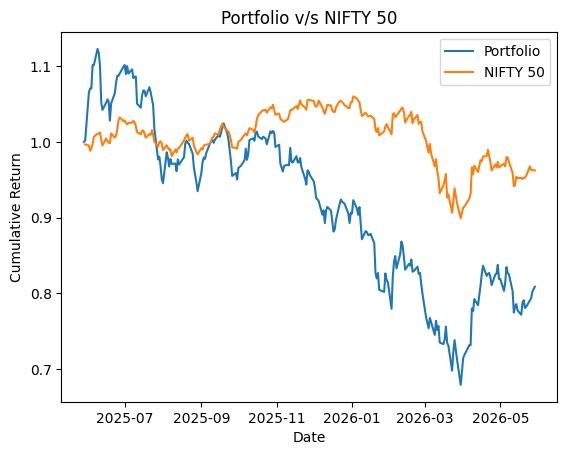

In [32]:
plt.plot(cumulative_return.index,cumulative_return, label= "Portfolio")
plt.plot(nifty_cumulative_return.index,nifty_cumulative_return, label = "NIFTY 50")
plt.title("Portfolio v/s NIFTY 50")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.savefig("portfolio_vs_nifty50.png")
plt.show()

In [18]:
def risk_metrics():
    returns = portfolio_daily_returns.dropna()
    nifty_returns = nifty_daily_returns.dropna()
    
    
    volatility = returns.std()*np.sqrt(252)
    sharpe_ratio = ((returns.mean()*252)-0.065)/volatility
    rolling_peak = cumulative_return.cummax()
    drawdown = (cumulative_return - rolling_peak) / rolling_peak
    max_drawdown = drawdown.min()
    return {
    "Volatility": float(volatility),
    "Sharpe Ratio": float(sharpe_ratio),
    "Max Drawdown": float(max_drawdown)
    }



In [19]:
risk_metrics()

{'Volatility': 0.27242039515559796,
 'Sharpe Ratio': -0.891947077705039,
 'Max Drawdown': -0.39540184534336376}

In [20]:
rolling_vol = daily_returns.rolling(30).std()*np.sqrt(252)
rolling_vol

Ticker,CDSL.NS,DEVYANI.NS,IREDA.NS,PLAZACABLE.NS
2025-05-29,NaN,NaN,NaN,NaN
2025-05-30,NaN,NaN,NaN,NaN
2025-06-02,NaN,NaN,NaN,NaN
2025-06-03,NaN,NaN,NaN,NaN
2025-06-04,NaN,NaN,NaN,NaN
...,...,...,...,...
2026-05-22,0.289143,0.533004,0.372486,0.857271
2026-05-25,0.285151,0.524340,0.372576,0.854360
2026-05-26,0.285452,0.520149,0.372455,0.856010
2026-05-27,0.264232,0.519955,0.366064,0.837190


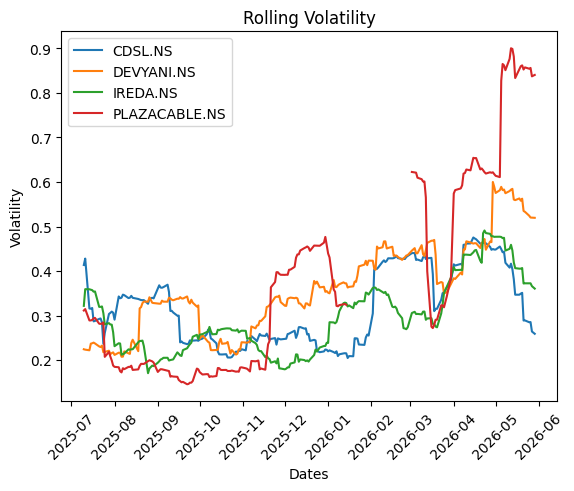

In [33]:
for stock in rolling_vol:
    plt.plot(rolling_vol.index,rolling_vol[stock],label=stock)
plt.title("Rolling Volatility")
plt.xlabel("Dates")  
plt.ylabel("Volatility")
plt.legend()
plt.xticks(rotation=45)
plt.savefig("Rolling_volatility.png")
plt.show()


In [22]:
corr_coef = daily_returns.corr()
corr_coef

Ticker,CDSL.NS,DEVYANI.NS,IREDA.NS,PLAZACABLE.NS
Ticker,,,,
CDSL.NS,1.000000,0.263738,0.575021,0.325715
DEVYANI.NS,0.263738,1.000000,0.349220,0.180045
IREDA.NS,0.575021,0.349220,1.000000,0.341332
PLAZACABLE.NS,0.325715,0.180045,0.341332,1.000000


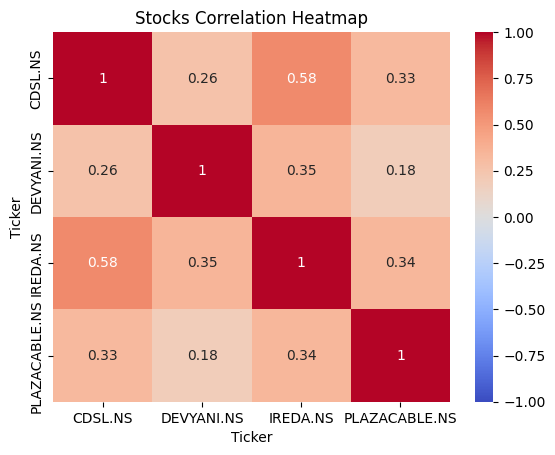

In [34]:
sns.heatmap(corr_coef, annot=True, cmap="coolwarm",vmin=-1,vmax=1)
plt.title("Stocks Correlation Heatmap")
plt.savefig("Stock_correlation_heatmap.png")
plt.show()

In [24]:
monthly_returns = portfolio_daily_returns.groupby(pd.Grouper(freq="ME")).apply(lambda x: (1+x).prod() - 1)
monthly_returns

2025-05-31    0.001927
2025-06-30    0.097063
2025-07-31   -0.135111
2025-08-31   -0.016586
2025-09-30    0.016628
2025-10-31    0.045101
2025-11-30   -0.037955
2025-12-31   -0.051684
2026-01-31   -0.101147
2026-02-28   -0.018338
2026-03-31   -0.151005
2026-04-30    0.206096
2026-05-31   -0.012368
Freq: ME, dtype: float64

In [25]:
monthly_df = pd.DataFrame({
    "Year": monthly_returns.index.year,
    "Month": monthly_returns.index.month,
    "Return": monthly_returns.values
})
monthly_df

,Year,Month,Return
0,2025,5,0.001927
1,2025,6,0.097063
2,2025,7,-0.135111
3,2025,8,-0.016586
4,2025,9,0.016628
5,2025,10,0.045101
6,2025,11,-0.037955
7,2025,12,-0.051684
8,2026,1,-0.101147
9,2026,2,-0.018338


In [26]:
heatmap_monthly_return = monthly_df.pivot(index="Year",columns="Month",values="Return")
heatmap_monthly_return

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2025,NaN,NaN,NaN,NaN,0.001927,0.097063,-0.135111,-0.016586,0.016628,0.045101,-0.037955,-0.051684
2026,-0.101147,-0.018338,-0.151005,0.206096,-0.012368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


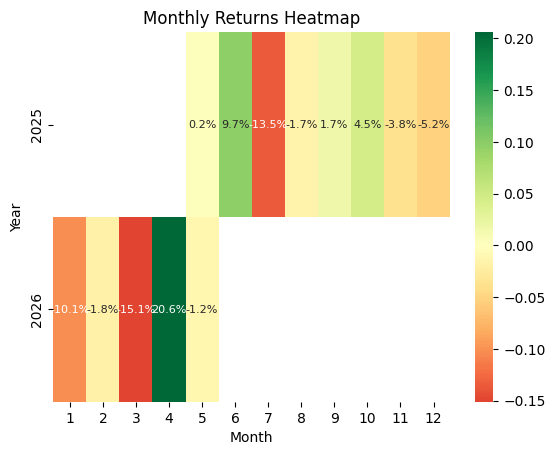

In [35]:
sns.heatmap(heatmap_monthly_return, annot=True, fmt=".1%", cmap="RdYlGn", center=0, annot_kws={"size": 8})
plt.title("Monthly Returns Heatmap")
plt.xlabel("Month")
plt.ylabel("Year")
plt.savefig("Monthly_returns_heatmap.png")
plt.show()

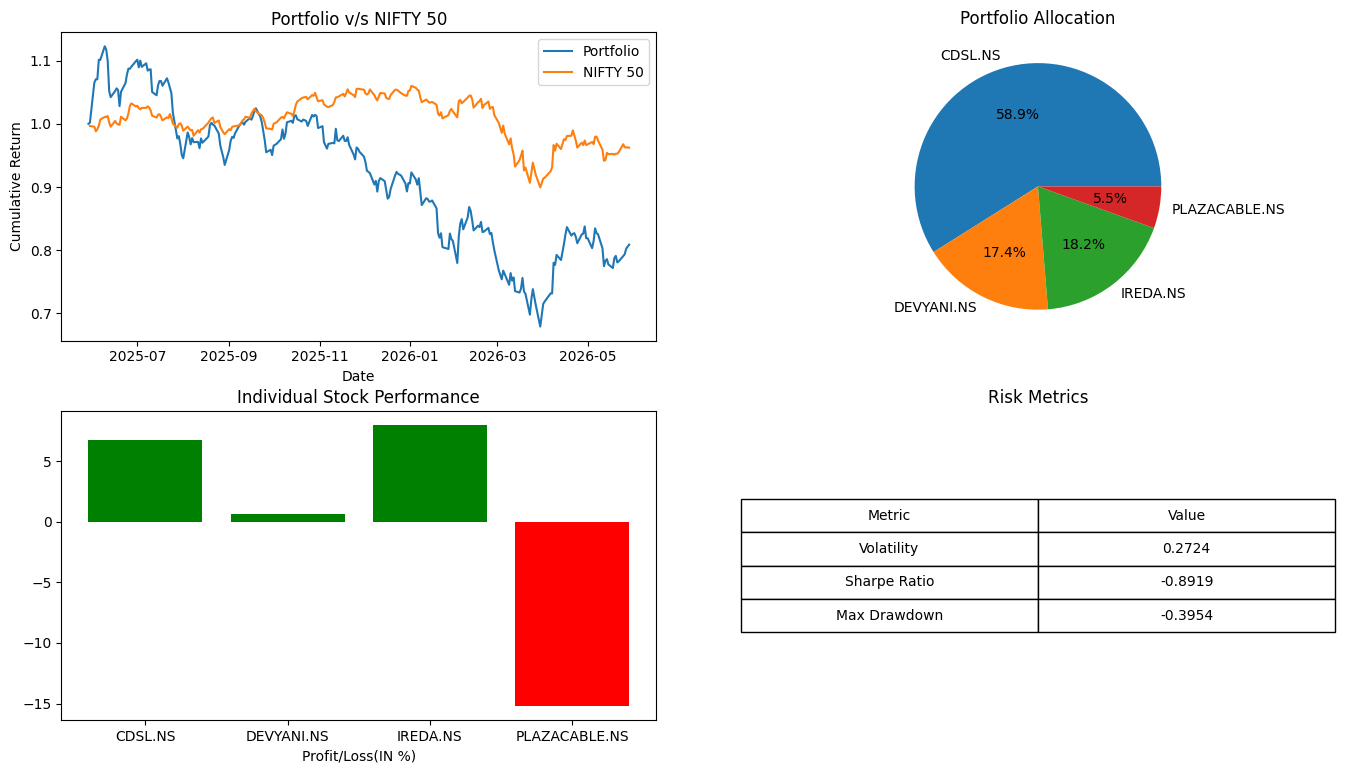

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plt.tight_layout(pad=3)

axes[0][0].plot(cumulative_return.index,cumulative_return,label="Portfolio")
axes[0][0].plot(nifty_cumulative_return.index,nifty_cumulative_return,label="NIFTY 50")
axes[0][0].set_title("Portfolio v/s NIFTY 50")
axes[0][0].set_xlabel("Date")
axes[0][0].set_ylabel("Cumulative Return")
axes[0][0].legend()

axes[0][1].pie(Portfolio_inv_each,labels = stock_name, autopct="%1.1f%%")
axes[0][1].set_title("Portfolio Allocation")

colors = ["green" if stock_name > 0 else "red" for stock_name in portfolio_summary()["Gain/Loss(In %)"]]
axes[1][0].bar(stock_name, portfolio_summary()["Gain/Loss(In %)"],color=colors)
axes[1][0].set_title("Individual Stock Performance")
axes[1][0].set_xlabel("Stock Name")
axes[1][0].set_xlabel("Profit/Loss(IN %)")

axes[1][1].axis("off")
metrics = risk_metrics()
table_data = [[k, round(v, 4)] for k, v in metrics.items()]

table = axes[1][1].table(
    cellText=table_data,
    colLabels=["Metric", "Value"],
    loc="center",
    cellLoc="center"
)
table.scale(1, 2)
axes[1][1].set_title("Risk Metrics")

plt.savefig("Dashboard.png")
plt.show()